<a href="https://colab.research.google.com/github/rka0285058-afk/Economic_Loss/blob/main/Economic_Loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Software/Input Output Analysis - Final.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded data from /content/drive/MyDrive/Software/Input Output Analysis - Final.csv.


,Industry Industry,Unnamed: 1,"Agriculture, hunting, forestry, and fishing",Mining and quarrying,"Food, beverages, and tobacco",Textiles and textile products,"Leather, leather products, and footwear",Wood and products of wood and cork,"Pulp, paper, paper products, printing, and publishing","Coke, refined petroleum, and nuclear fuel",...,Unnamed: 277,Unnamed: 278,Unnamed: 279,Unnamed: 280,Unnamed: 281,Unnamed: 282,Unnamed: 283,Unnamed: 284,Unnamed: 285,Unnamed: 286
0,NaN,NaN,c1,c2,c3,c4,c5,c6,c7,c8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Agriculture, hunting, forestry, and fishing",c1,"48,026",0,"66,966","11,351","1,455","5,932","1,416",5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mining and quarrying,c2,-,111,48,188,6,52,138,"24,890",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Food, beverages, and tobacco",c3,"2,698",22,"26,090",534,52,35,202,62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Textiles and textile products,c4,964,49,448,"24,969",217,94,289,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing for Input-Output Analysis

The initial DataFrame contains metadata in the first few rows and columns, as well as non-numeric values. To prepare it for the Leontief model, we need to:

1.  **Set the correct header:** The industry names for both input and output sectors appear to be in the first row (index 0) of the loaded DataFrame, after skipping the initial metadata.
2.  **Identify the relevant data block:** The actual input-output data starts from the second row (index 1) and specific columns.
3.  **Convert data to numeric:** Ensure all values in the input-output matrix are numeric.
4.  **Handle non-numeric values:** Replace '-' with 0 or NaN as appropriate, and convert other data to numeric.

In [ ]:
import numpy as np
import pandas as pd

# Reload the CSV without a header to better control parsing
raw_df = pd.read_csv(file_path, header=None, na_values=['-'])

# --- 1. Identify all meaningful column headers from the second row (index 1) ---
# Start from column index 2, as the first two columns (index 0 and 1) are descriptive.
all_potential_headers = raw_df.iloc[1, 2:].dropna().tolist()

# --- 2. Identify actual transaction sector codes (e.g., 'c1' to 'c35') ---
transaction_sector_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('c') and h[1:].isdigit()]
num_transaction_sectors = len(transaction_sector_codes) # This should be 35

# --- 3. Identify final demand column headers (e.g., 'F1' to 'F6') ---
final_demand_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('F') and h[1:].isdigit()]

# --- 4. Identify 'Total Output' column header (if it exists) ---
total_output_header_label = None
for h in all_potential_headers:
    if isinstance(h, str) and ('total output' in h.lower() or 'total gross output' in h.lower()):
        total_output_header_label = h
        break

# --- 5. Create a mapping from sector code to full industry name ---
sector_code_to_name = {}
# The full industry names are in raw_df.iloc[0], aligned with the codes in raw_df.iloc[1]
# The first two columns of raw_df (index 0 and 1) are descriptive.
for col_idx in range(2, raw_df.shape[1]):
    code = raw_df.iloc[1, col_idx]
    name = raw_df.iloc[0, col_idx]
    if isinstance(code, str) and code.startswith('c') and code[1:].isdigit():
        if isinstance(name, str) and name != 'Industry': # Avoid 'Industry' placeholder
            sector_code_to_name[code] = name

# --- 6. Extract Z matrix (transaction matrix) ---
# The transaction sectors start from raw_df column index 2 and continue for num_transaction_sectors columns.
z_cols_start_idx = 2
z_cols_end_idx = z_cols_start_idx + num_transaction_sectors

if not transaction_sector_codes:
    raise ValueError("No transaction sector codes found. Cannot extract Z matrix.")

# Extract the Z matrix data block. Rows are for 'from' sectors, columns for 'to' sectors.
Z_matrix_df = raw_df.iloc[2:2 + num_transaction_sectors, z_cols_start_idx : z_cols_end_idx].copy()
Z_matrix_df.columns = transaction_sector_codes
Z_matrix_df.index = raw_df.iloc[2:2 + num_transaction_sectors, 1].tolist() # 'c' codes for row index names

# Clean and convert Z matrix to numeric
Z_matrix_df = Z_matrix_df.replace({',': ''}, regex=True)
Z_matrix_df = Z_matrix_df.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Extracted Transaction Matrix (Z) (first 5x5):")
display(Z_matrix_df.head())

# --- 7. Extract Final Demand vector (delta_f) ---
# Final demand columns start right after the transaction sectors.
fd_cols_start_idx = z_cols_end_idx
fd_cols_end_idx = fd_cols_start_idx + len(final_demand_codes)

if not final_demand_codes:
    raise ValueError("No final demand codes found. Cannot extract final demand vector.")

final_demand_df = raw_df.iloc[2:2 + num_transaction_sectors, fd_cols_start_idx : fd_cols_end_idx].copy()
final_demand_df = final_demand_df.replace({',': ''}, regex=True)
final_demand_vector = final_demand_df.apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).values # Sum F1-F6 for each sector

print("\nExtracted Final Demand Vector (first 5 values):")
print(final_demand_vector[:5])

# --- 8. Extract or Calculate Total Output (X) vector ---
total_output_vector = None
if total_output_header_label:
    # Find the actual column index for 'Total Output' by iterating through the second row of raw_df
    x_col_idx = -1
    for i in range(raw_df.shape[1]):
        if str(raw_df.iloc[1, i]) == total_output_header_label:
            x_col_idx = i
            break

    if x_col_idx != -1:
        total_output_vector_str = raw_df.iloc[2:2 + num_transaction_sectors, x_col_idx].copy()
        total_output_vector_str = total_output_vector_str.replace({',': ''}, regex=True)
        total_output_vector = total_output_vector_str.apply(pd.to_numeric, errors='coerce').fillna(0).values
    else:
        # Fallback if label was identified but its precise column index could not be found
        print("\nWarning: 'Total Output' column header was identified, but its precise column index could not be found in raw_df.iloc[1]. Calculating as sum of Z row-wise + Final Demand.")
        total_output_vector = Z_matrix_df.sum(axis=1).values + final_demand_vector
else:
    # If 'Total Output' column is not explicitly labeled, calculate it as Z row sums + final demand
    print("\n'Total Output' column not found directly. Calculating as sum of Z row-wise + Final Demand.")
    total_output_vector = Z_matrix_df.sum(axis=1).values + final_demand_vector

# Ensure total_output_vector is a 1D array and has positive values for division
if (total_output_vector <= 0).any():
    print("Warning: Some total output values are zero or negative. Adjusting to avoid division by zero.")
    total_output_vector[total_output_vector <= 0] = np.finfo(float).eps # Use a small positive number to avoid division by zero

# Calculate the Technical Coefficients Matrix (A)
# A_ij = Z_ij / X_j (column-wise division, where X_j is the total output of sector j)
A_matrix = Z_matrix_df.values / total_output_vector[np.newaxis, :]

# Convert A_matrix back to DataFrame for better handling and display
A_matrix_df = pd.DataFrame(A_matrix, index=Z_matrix_df.index, columns=Z_matrix_df.columns)

print("\nTechnical Coefficients Matrix (A) (first 5x5):")
display(A_matrix_df.head())

# Now, calculate the Leontief Inverse (I - A)^-1
num_sectors_A = A_matrix_df.shape[0]
I = np.identity(num_sectors_A) # Identity matrix

# Calculate (I - A)
I_minus_A = I - A_matrix_df.values

# Calculate the Leontief Inverse (I - A)^-1
try:
    leontief_inverse = np.linalg.inv(I_minus_A)
    print("\nLeontief Inverse (first 5x5 rows/cols):")
    display(pd.DataFrame(leontief_inverse, index=A_matrix_df.index, columns=A_matrix_df.columns).head())

    # Define the direct losses
    direct_losses_billion = 29
    direct_losses_million = direct_losses_billion * 1000 # Convert to Million $ for consistency with assumed Z units

    # Interpret 'direct losses of 29 Billion $' as a total reduction in final demand,
    # distributed proportionally to each sector's current final demand.
    total_current_final_demand = final_demand_vector.sum()
    if total_current_final_demand == 0:
        # If there's no final demand, distribute equally
        print("Warning: Total current final demand is zero. Distributing direct losses equally.")
        delta_f_shock = np.full(num_sectors_A, direct_losses_million / num_sectors_A)
    else:
        proportional_distribution = final_demand_vector / total_current_final_demand
        delta_f_shock = proportional_distribution * direct_losses_million

    # Calculate the total output change (delta_x) due to the shock
    # delta_x = L * delta_f_shock, where L is the Leontief Inverse
    delta_x = leontief_inverse @ delta_f_shock

    # Calculate indirect losses
    # Indirect losses for each sector are the total output change minus the direct final demand change (shock)
    indirect_losses_million = delta_x - delta_f_shock

    print(f"\nIndirect Losses per sector (in Billion $ for a total direct loss of {direct_losses_billion} Billion $ distributed proportionally to current final demand):\n")
    indirect_losses_df = pd.DataFrame({
        'Sector Code': Z_matrix_df.index,
        'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
        'Indirect Loss (Billion $)': indirect_losses_million / 1000 # Convert back to Billion $
    })
    # Sort by indirect loss for better readability
    indirect_losses_df = indirect_losses_df.sort_values(by='Indirect Loss (Billion $)', ascending=False)
    display(indirect_losses_df)

    print(f"\nTotal Indirect Losses: {indirect_losses_million.sum() / 1000:,.2f} Billion $")
    print(f"Total Direct Losses (shock): {delta_f_shock.sum() / 1000:,.2f} Billion $")
    print(f"Total Output Change: {delta_x.sum() / 1000:,.2f} Billion $")

except np.linalg.LinAlgError:
    print("Error: The Leontief Inverse could not be calculated. This usually means (I - A) is singular. Check the A matrix.")
except ValueError as e:
    print(f"Error during data processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Extracted Transaction Matrix (Z) (first 5x5):


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,...,c26,c27,c28,c29,c30,c31,c32,c33,c34,c35
c1,48026.0,0.0,66966.0,11351.0,1455.0,5932.0,1416.0,5.0,1505.0,2009.0,...,0.0,0.0,1.0,2.0,38.0,0.0,99.0,274.0,27.0,0.0
c2,0.0,111.0,48.0,188.0,6.0,52.0,138.0,24890.0,1201.0,16.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
c3,2698.0,22.0,26090.0,534.0,52.0,35.0,202.0,62.0,3846.0,445.0,...,3.0,1.0,53.0,1.0,10.0,0.0,7.0,109.0,10.0,0.0
c4,964.0,49.0,448.0,24969.0,217.0,94.0,289.0,25.0,897.0,1166.0,...,29.0,10.0,82.0,3.0,102.0,0.0,69.0,306.0,47.0,0.0
c5,34.0,8.0,74.0,562.0,3781.0,15.0,19.0,5.0,118.0,219.0,...,11.0,1.0,9.0,0.0,7.0,0.0,4.0,31.0,2.0,0.0



Extracted Final Demand Vector (first 5 values):
[248862.   8117. 150083.  99879.  11602.]

'Total Output' column not found directly. Calculating as sum of Z row-wise + Final Demand.

Technical Coefficients Matrix (A) (first 5x5):


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,...,c26,c27,c28,c29,c30,c31,c32,c33,c34,c35
c1,0.115604,0.000000,0.337072,0.083273,0.080183,0.215185,0.044679,0.000033,0.009882,0.039198,...,0.000000,0.000000,0.000007,0.000014,0.000266,0.0,0.001069,0.005730,0.000433,0.0
c2,0.000000,0.002180,0.000242,0.001379,0.000331,0.001886,0.004354,0.162333,0.007886,0.000312,...,0.000000,0.000000,0.000000,0.000000,0.000007,0.0,0.000000,0.000000,0.000016,0.0
c3,0.006494,0.000432,0.131323,0.003918,0.002866,0.001270,0.006374,0.000404,0.025253,0.008683,...,0.000203,0.000036,0.000387,0.000007,0.000070,0.0,0.000076,0.002279,0.000160,0.0
c4,0.002320,0.000962,0.002255,0.183178,0.011959,0.003410,0.009119,0.000163,0.005890,0.022750,...,0.001967,0.000361,0.000598,0.000021,0.000714,0.0,0.000745,0.006399,0.000753,0.0
c5,0.000082,0.000157,0.000372,0.004123,0.208365,0.000544,0.000600,0.000033,0.000775,0.004273,...,0.000746,0.000036,0.000066,0.000000,0.000049,0.0,0.000043,0.000648,0.000032,0.0



Leontief Inverse (first 5x5 rows/cols):


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,...,c26,c27,c28,c29,c30,c31,c32,c33,c34,c35
c1,1.136903,0.005163,0.449955,0.130725,0.129926,0.256788,0.085898,0.002278,0.042053,0.077050,...,0.027892,0.002397,0.007963,0.002614,0.009157,0.0,0.006647,0.033687,0.004934,0.0
c2,0.002747,1.008042,0.006535,0.010908,0.007723,0.006911,0.015807,0.167936,0.023114,0.013124,...,0.006794,0.003000,0.002348,0.001262,0.002220,0.0,0.001462,0.005575,0.001979,0.0
c3,0.010035,0.002621,1.157789,0.011977,0.010321,0.006568,0.015793,0.001612,0.042776,0.025241,...,0.014126,0.000930,0.004332,0.000844,0.004615,0.0,0.002662,0.018678,0.001609,0.0
c4,0.004041,0.002525,0.006840,1.228442,0.022560,0.007309,0.018203,0.000999,0.013050,0.037762,...,0.005893,0.001358,0.001730,0.000438,0.001937,0.0,0.001734,0.011095,0.001966,0.0
c5,0.000319,0.000524,0.001191,0.007298,1.264266,0.001329,0.002007,0.000222,0.002143,0.007455,...,0.001768,0.000290,0.000304,0.000059,0.000256,0.0,0.000271,0.001431,0.000258,0.0



Indirect Losses per sector (in Billion $ for a total direct loss of 29 Billion $ distributed proportionally to current final demand):



,Sector Code,Full Industry Name,Indirect Loss (Billion $)
0,c1,"Agriculture, hunting, forestry, and fishing",2.004036
11,c12,Basic metals and fabricated metal,1.842978
20,c21,"Retail trade, except of motor vehicles and mot...",1.585505
22,c23,Inland transport,1.456954
8,c9,Chemicals and chemical products,1.121798
27,c28,Financial intermediation,1.111752
17,c18,Construction,1.050731
19,c20,"Wholesale trade and commission trade, except o...",0.971074
7,c8,"Coke, refined petroleum, and nuclear fuel",0.792018
16,c17,"Electricity, gas, and water supply",0.735196



Total Indirect Losses: 18.94 Billion $
Total Direct Losses (shock): 29.00 Billion $
Total Output Change: 47.94 Billion $


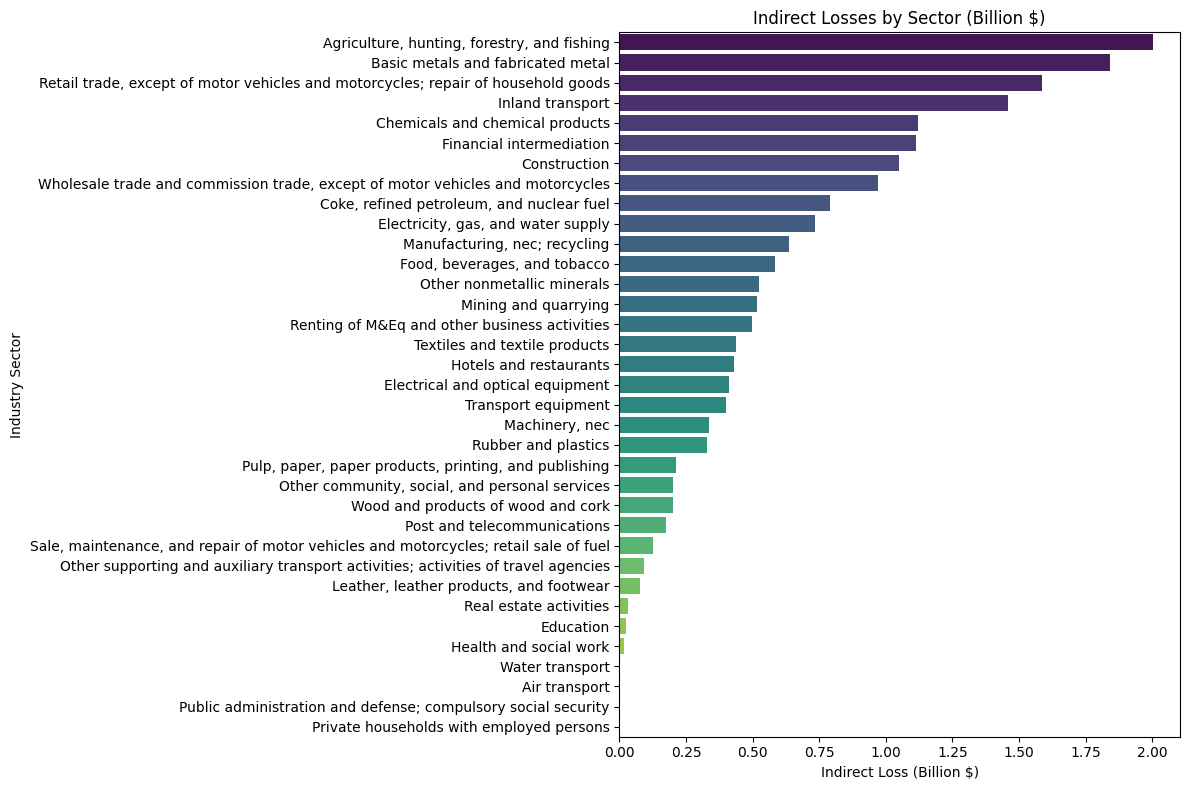

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame for better visualization
indirect_losses_df_sorted = indirect_losses_df.sort_values(by='Indirect Loss (Billion $)', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Indirect Loss (Billion $)', y='Full Industry Name', hue='Full Industry Name', data=indirect_losses_df_sorted, palette='viridis', legend=False)
plt.title('Indirect Losses by Sector (Billion $)')
plt.xlabel('Indirect Loss (Billion $)')
plt.ylabel('Industry Sector')
plt.tight_layout()
plt.show()

### Estimating Initial Capital Stock (K0)

Following the steady-state assumption, the initial capital stock for each sector will be estimated using the formula:

**K0 = I0 / (g + δ)**

Where:
-   **K0** is the initial capital stock.
-   **I0** is the initial investment, for which we are using the `final_demand_vector` as a proxy.
-   **g** is the assumed growth rate (0.05).
-   **δ** is the assumed depreciation rate (0.05).

In [ ]:
import numpy as np
import pandas as pd

# Assume growth rate (g) and depreciation rate (delta)
# Based on the user's request: 5% growth and 5% depreciation
growth_rate = 0.05
depreciation_rate = 0.05

# Use final_demand_vector as a proxy for initial investment (I0)
# final_demand_vector is already in Million $ from previous calculations
initial_investment_proxy = final_demand_vector

# Calculate initial capital stock (K0) for each sector
# K0 = I0 / (g + delta)
initial_capital_stock = initial_investment_proxy / (growth_rate + depreciation_rate)

# Create a DataFrame for better display
initial_capital_stock_df = pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Initial Capital Stock (Million $)': initial_capital_stock
})

print("Calculated Initial Capital Stock per sector (in Million $):")
display(initial_capital_stock_df.head())
display(initial_capital_stock_df.tail())

print(f"\nTotal Initial Capital Stock (across all sectors): {initial_capital_stock.sum():,.2f} Million $")

Calculated Initial Capital Stock per sector (in Million $):


,Sector Code,Full Industry Name,Initial Capital Stock (Million $)
0,c1,"Agriculture, hunting, forestry, and fishing",2488620.0
1,c2,Mining and quarrying,81170.0
2,c3,"Food, beverages, and tobacco",1500830.0
3,c4,Textiles and textile products,998790.0
4,c5,"Leather, leather products, and footwear",116020.0


,Sector Code,Full Industry Name,Initial Capital Stock (Million $)
30,c31,Public administration and defense; compulsory ...,1410130.0
31,c32,Education,903870.0
32,c33,Health and social work,463940.0
33,c34,"Other community, social, and personal services",456630.0
34,c35,Private households with employed persons,0.0



Total Initial Capital Stock (across all sectors): 24,104,590.00 Million $


### Calculating the Capital Coefficient Matrix (B)

With the estimated initial capital stock and the total output vector, we can now calculate the Capital Coefficient Matrix (B). This matrix quantifies the amount of capital stock required to produce one unit of output in each sector. Since we have a single vector of initial capital stock for each sector, we will construct a diagonal `B` matrix, where `B_jj = K_j / X_j`.

Where:
-   **K_j** is the initial capital stock of sector `j`.
-   **X_j** is the total output of sector `j`.

In [ ]:
# Calculate the capital coefficients for each sector (K_j / X_j)
# We need to ensure total_output_vector has no zero values to avoid division by zero
# This was handled in the preprocessing step by setting zero outputs to a small epsilon.
capital_coefficients_vector = initial_capital_stock / total_output_vector

# Create a diagonal Capital Coefficient Matrix (B)
# The B matrix will be a 35x35 diagonal matrix where B_jj is the capital coefficient for sector j
B_matrix = np.diag(capital_coefficients_vector)

# Convert B_matrix to a DataFrame for better display with sector labels
B_matrix_df = pd.DataFrame(B_matrix, index=Z_matrix_df.index, columns=Z_matrix_df.columns)

print("Capital Coefficients per sector:")
display(pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Capital Coefficient (K/X)': capital_coefficients_vector
}).head())
display(pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Capital Coefficient (K/X)': capital_coefficients_vector
}).tail())

print("\nCapital Coefficient Matrix (B) (first 5x5, will be mostly zeros off-diagonal):")
display(B_matrix_df.head())

Capital Coefficients per sector:


,Sector Code,Full Industry Name,Capital Coefficient (K/X)
0,c1,"Agriculture, hunting, forestry, and fishing",5.990381
1,c2,Mining and quarrying,1.594007
2,c3,"Food, beverages, and tobacco",7.554387
3,c4,Textiles and textile products,7.327342
4,c5,"Leather, leather products, and footwear",6.393696


,Sector Code,Full Industry Name,Capital Coefficient (K/X)
30,c31,Public administration and defense; compulsory ...,10.000000
31,c32,Education,9.763651
32,c33,Health and social work,9.701393
33,c34,"Other community, social, and personal services",7.318140
34,c35,Private households with employed persons,0.000000



Capital Coefficient Matrix (B) (first 5x5, will be mostly zeros off-diagonal):


,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,...,c26,c27,c28,c29,c30,c31,c32,c33,c34,c35
c1,5.990381,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c2,0.000000,1.594007,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c3,0.000000,0.000000,7.554387,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c4,0.000000,0.000000,0.000000,7.327342,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c5,0.000000,0.000000,0.000000,0.000000,6.393696,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculating Recovery Period for Each Sector

Now that we have the Capital Coefficient Matrix (B) and the total output change (`delta_x`) due to the initial shock, we can estimate a recovery period for each sector.

We will define the recovery period as the time it takes for a sector to generate the additional output required to return to its pre-shock output trajectory, given its assumed steady-state growth rate.

The formula for the recovery period (`T_j`) for each sector `j` is derived from the net capital accumulation and required output recovery:

**T_j = (Capital Required to Recover Output_j) / (Net Annual Capital Accumulation_j)**

Substituting `Capital Required to Recover Output_j = B_jj * delta_x_j` and `Net Annual Capital Accumulation_j = growth_rate * Initial Capital Stock_j`.

Since `B_jj = Initial Capital Stock_j / Total Output_j`,

**T_j = (B_jj * delta_x_j) / (growth_rate * Initial Capital Stock_j)**

This simplifies to:

**T_j = delta_x_j / (growth_rate * total_output_vector_j)**

Where:
-   **delta_x_j** is the total change in output for sector `j` (the output that needs to be recovered or added).
-   **growth_rate** is the assumed annual growth rate (g = 0.05 or 5%).
-   **total_output_vector_j** is the initial total output of sector `j`.

In [ ]:
# Ensure delta_x and total_output_vector are numpy arrays for element-wise division
delta_x = np.array(delta_x)
total_output_vector = np.array(total_output_vector)

# Ensure growth_rate is not zero to avoid division by zero
if growth_rate == 0:
    print("Warning: Growth rate is zero, recovery period cannot be calculated using this formula.")
    # Set recovery_period to infinity or a very large number if growth_rate is 0
    recovery_period_years = np.full_like(delta_x, np.inf)
else:
    # Calculate the recovery period for each sector (in years)
    # We've already ensured total_output_vector has no zero values by replacing them with epsilon.
    recovery_period_years = delta_x / (growth_rate * total_output_vector)

# Create a DataFrame for better display
recovery_period_df = pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Required Output Change (Million $)': delta_x,
    'Initial Total Output (Million $)': total_output_vector,
    'Recovery Period (Years)': recovery_period_years
})

# Sort by recovery period for better readability
recovery_period_df_sorted = recovery_period_df.sort_values(by='Recovery Period (Years)', ascending=False)

print("Recovery Period per sector (in Years):")
display(recovery_period_df_sorted.head())
display(recovery_period_df_sorted.tail())

print(f"\nAverage Recovery Period (across all sectors): {recovery_period_years.mean():,.2f} Years")

Recovery Period per sector (in Years):


,Sector Code,Full Industry Name,Required Output Change (Million $),Initial Total Output (Million $),Recovery Period (Years)
19,c20,"Wholesale trade and commission trade, except o...",1841.895257,153097.0,0.240618
28,c29,Real estate activities,1691.208189,140572.0,0.240618
21,c22,Hotels and restaurants,1055.820074,87759.0,0.240618
20,c21,"Retail trade, except of motor vehicles and mot...",3007.725914,250000.0,0.240618
32,c33,Health and social work,575.341875,47822.0,0.240618


,Sector Code,Full Industry Name,Required Output Change (Million $),Initial Total Output (Million $),Recovery Period (Years)
10,c11,Other nonmetallic minerals,663.432151,5.514400e+04,0.240618
11,c12,Basic metals and fabricated metal,2814.533664,2.339420e+05,0.240618
13,c14,Electrical and optical equipment,889.312367,7.391900e+04,0.240618
8,c9,Chemicals and chemical products,1832.282565,1.522980e+05,0.240618
34,c35,Private households with employed persons,0.000000,2.220446e-16,0.000000



Average Recovery Period (across all sectors): 0.23 Years


### Sectors with the Longest Recovery Times

Based on the calculated recovery periods, here are the top sectors that are estimated to take the longest to recover, assuming a 5% annual growth rate:


In [ ]:
print("Top 10 Sectors with the Longest Recovery Times:")
display(recovery_period_df_sorted.head(10))

Top 10 Sectors with the Longest Recovery Times:


,Sector Code,Full Industry Name,Required Output Change (Million $),Initial Total Output (Million $),Recovery Period (Years)
19,c20,"Wholesale trade and commission trade, except o...",1841.895257,153097.0,0.240618
28,c29,Real estate activities,1691.208189,140572.0,0.240618
21,c22,Hotels and restaurants,1055.820074,87759.0,0.240618
20,c21,"Retail trade, except of motor vehicles and mot...",3007.725914,250000.0,0.240618
32,c33,Health and social work,575.341875,47822.0,0.240618
1,c2,Mining and quarrying,612.637676,50922.0,0.240618
15,c16,"Manufacturing, nec; recycling",1481.076426,123106.0,0.240618
25,c26,Other supporting and auxiliary transport activ...,177.395674,14745.0,0.240618
0,c1,"Agriculture, hunting, forestry, and fishing",4998.070492,415436.0,0.240618
29,c30,Renting of M&Eq and other business activities,1717.796486,142782.0,0.240618


### Recovery Period for the Worst Hit Sector

Let's identify the sector with the highest indirect losses and display its estimated recovery period.

In [ ]:
import pandas as pd
import numpy as np

# Re-establish file_path and raw_df (assuming it's still available)
# Note: This block assumes '/content/drive/MyDrive/Software/Input Output Analysis - Final.csv' is accessible.
file_path = '/content/drive/MyDrive/Software/Input Output Analysis - Final.csv'
try:
    raw_df = pd.read_csv(file_path, header=None, na_values=['-'])
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
    raise # Re-raise to stop execution if file is not found

# --- Re-extract essential variables for calculations (from cell a91cea47) ---
all_potential_headers = raw_df.iloc[1, 2:].dropna().tolist()
transaction_sector_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('c') and h[1:].isdigit()]
num_transaction_sectors = len(transaction_sector_codes)
final_demand_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('F') and h[1:].isdigit()]

sector_code_to_name = {}
for col_idx in range(2, raw_df.shape[1]):
    code = raw_df.iloc[1, col_idx]
    name = raw_df.iloc[0, col_idx]
    if isinstance(code, str) and code.startswith('c') and code[1:].isdigit():
        if isinstance(name, str) and name != 'Industry':
            sector_code_to_name[code] = name

z_cols_start_idx = 2
z_cols_end_idx = z_cols_start_idx + num_transaction_sectors
Z_matrix_df = raw_df.iloc[2:2 + num_transaction_sectors, z_cols_start_idx : z_cols_end_idx].copy()
Z_matrix_df.columns = transaction_sector_codes
Z_matrix_df.index = raw_df.iloc[2:2 + num_transaction_sectors, 1].tolist()
Z_matrix_df = Z_matrix_df.replace({',': ''}, regex=True)
Z_matrix_df = Z_matrix_df.apply(pd.to_numeric, errors='coerce').fillna(0)

fd_cols_start_idx = z_cols_end_idx
fd_cols_end_idx = fd_cols_start_idx + len(final_demand_codes)
final_demand_df = raw_df.iloc[2:2 + num_transaction_sectors, fd_cols_start_idx : fd_cols_end_idx].copy()
final_demand_df = final_demand_df.replace({',': ''}, regex=True)
final_demand_vector = final_demand_df.apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).values

total_output_vector = Z_matrix_df.sum(axis=1).values + final_demand_vector
total_output_vector[total_output_vector <= 0] = np.finfo(float).eps # Avoid division by zero

num_sectors_A = Z_matrix_df.shape[0]
A_matrix = Z_matrix_df.values / total_output_vector[np.newaxis, :]
A_matrix_df = pd.DataFrame(A_matrix, index=Z_matrix_df.index, columns=Z_matrix_df.columns)
I = np.identity(num_sectors_A)
I_minus_A = I - A_matrix_df.values
try:
    leontief_inverse = np.linalg.inv(I_minus_A)
except np.linalg.LinAlgError:
    print("Error: The Leontief Inverse could not be calculated. This usually means (I - A) is singular. Check the A matrix.")
    raise # Re-raise to stop execution

# Direct and Indirect Losses calculation (from cell a91cea47)
direct_losses_billion = 29
direct_losses_million = direct_losses_billion * 1000
total_current_final_demand = final_demand_vector.sum()
if total_current_final_demand == 0:
    delta_f_shock = np.full(num_sectors_A, direct_losses_million / num_sectors_A)
else:
    proportional_distribution = final_demand_vector / total_current_final_demand
    delta_f_shock = proportional_distribution * direct_losses_million
delta_x = leontief_inverse @ delta_f_shock
indirect_losses_million = delta_x - delta_f_shock

# Define indirect_losses_df and then its sorted version
indirect_losses_df = pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Indirect Loss (Billion $)': indirect_losses_million / 1000 # Convert back to Billion $
})
indirect_losses_df_sorted = indirect_losses_df.sort_values(by='Indirect Loss (Billion $)', ascending=False)

# Recovery Period Calculation (from cell 9b293925)
growth_rate = 0.05 # Assumed growth rate
depreciation_rate = 0.05 # Assumed depreciation rate (not directly used here, but for context)

# Ensure delta_x and total_output_vector are numpy arrays for element-wise division
delta_x = np.array(delta_x)
total_output_vector = np.array(total_output_vector)

if growth_rate == 0:
    recovery_period_years = np.full_like(delta_x, np.inf)
else:
    recovery_period_years = delta_x / (growth_rate * total_output_vector)

# Define recovery_period_df and then its sorted version
recovery_period_df = pd.DataFrame({
    'Sector Code': Z_matrix_df.index,
    'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
    'Required Output Change (Million $)': delta_x,
    'Initial Total Output (Million $)': total_output_vector,
    'Recovery Period (Years)': recovery_period_years
})
recovery_period_df_sorted = recovery_period_df.sort_values(by='Recovery Period (Years)', ascending=False)

# Identify the worst-hit sector based on indirect losses
worst_hit_sector_code = indirect_losses_df_sorted.iloc[0]['Sector Code']
worst_hit_sector_name = indirect_losses_df_sorted.iloc[0]['Full Industry Name']

# Filter the recovery_period_df_sorted for this sector
worst_hit_recovery = recovery_period_df_sorted[recovery_period_df_sorted['Sector Code'] == worst_hit_sector_code]

print(f"Recovery period for the worst-hit sector ('{worst_hit_sector_name}' - {worst_hit_sector_code}):")
display(worst_hit_recovery)


Recovery period for the worst-hit sector ('Agriculture, hunting, forestry, and fishing' - c1):


,Sector Code,Full Industry Name,Required Output Change (Million $),Initial Total Output (Million $),Recovery Period (Years)
0,c1,"Agriculture, hunting, forestry, and fishing",4998.070492,415436.0,0.240618


### Accumulated Losses for Retail Trade Sector

To understand the progression of losses, we will calculate the accumulated indirect losses for the retail sector over various time intervals (30, 60, ..., 360 days). We assume a linear accumulation of the total indirect loss up to the calculated recovery period for the sector.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the worst-hit sector code identified earlier
target_sector_code = worst_hit_sector_code
target_sector_name = worst_hit_sector_name

# Extract relevant data for the target sector
target_data = recovery_period_df_sorted[recovery_period_df_sorted['Sector Code'] == target_sector_code].iloc[0]
target_indirect_loss_billion = indirect_losses_df[indirect_losses_df['Sector Code'] == target_sector_code]['Indirect Loss (Billion $)'].iloc[0]

# Convert total indirect loss to Million $ for consistency with internal calculations
target_indirect_loss_million = target_indirect_loss_billion * 1000
target_recovery_period_years = target_data['Recovery Period (Years)']

# Define the time points in days for calculation
days_list = np.arange(30, 361, 30)

# Convert days to years for consistency with recovery period
elapsed_time_years = days_list / 365.0

# Calculate accumulated losses and daily rate of loss accumulation
accumulated_losses_million = []
daily_loss_accumulation_rate = []

# Calculate the constant daily rate of loss accumulation during the recovery phase
# This rate is total indirect loss / (recovery_period_years * 365 days/year)
# If recovery_period_years is 0, handle it to avoid division by zero.
if target_recovery_period_years > 0:
    constant_daily_rate = target_indirect_loss_million / (target_recovery_period_years * 365)
else:
    constant_daily_rate = 0 # No accumulation if recovery period is 0

for t_years in elapsed_time_years:
    if t_years <= target_recovery_period_years:
        # Proportional accumulation up to the recovery period
        acc_loss = target_indirect_loss_million * (t_years / target_recovery_period_years)
        rate = constant_daily_rate
    else:
        # Once full recovery period is passed, accumulated loss equals the total indirect loss
        acc_loss = target_indirect_loss_million
        rate = 0 # No further accumulation of *these* indirect losses
    accumulated_losses_million.append(acc_loss)
    daily_loss_accumulation_rate.append(rate)


# Create a DataFrame to display the results
accumulated_losses_df = pd.DataFrame({
    'Elapsed Time (Days)': days_list,
    'Elapsed Time (Years)': elapsed_time_years,
    'Accumulated Losses (Million $)': accumulated_losses_million,
    'Daily Loss Accumulation Rate (Million $/Day)': daily_loss_accumulation_rate # New column
})

print(f"Accumulated Indirect Losses and Daily Accumulation Rate for {target_sector_name} ({target_sector_code}):")
display(accumulated_losses_df)

Accumulated Indirect Losses and Daily Accumulation Rate for Agriculture, hunting, forestry, and fishing (c1):


,Elapsed Time (Days),Elapsed Time (Years),Accumulated Losses (Million $),Daily Loss Accumulation Rate (Million $/Day)
0,30,0.082192,684.550685,22.818356
1,60,0.164384,1369.101370,22.818356
2,90,0.246575,2004.035746,0.000000
3,120,0.328767,2004.035746,0.000000
4,150,0.410959,2004.035746,0.000000
5,180,0.493151,2004.035746,0.000000
6,210,0.575342,2004.035746,0.000000
7,240,0.657534,2004.035746,0.000000
8,270,0.739726,2004.035746,0.000000
9,300,0.821918,2004.035746,0.000000


### Plot of Accumulated Losses vs. Elapsed Time

The following plot visualizes how the accumulated indirect losses for the retail sector progress over time, reaching the total indirect loss once the recovery period is met.


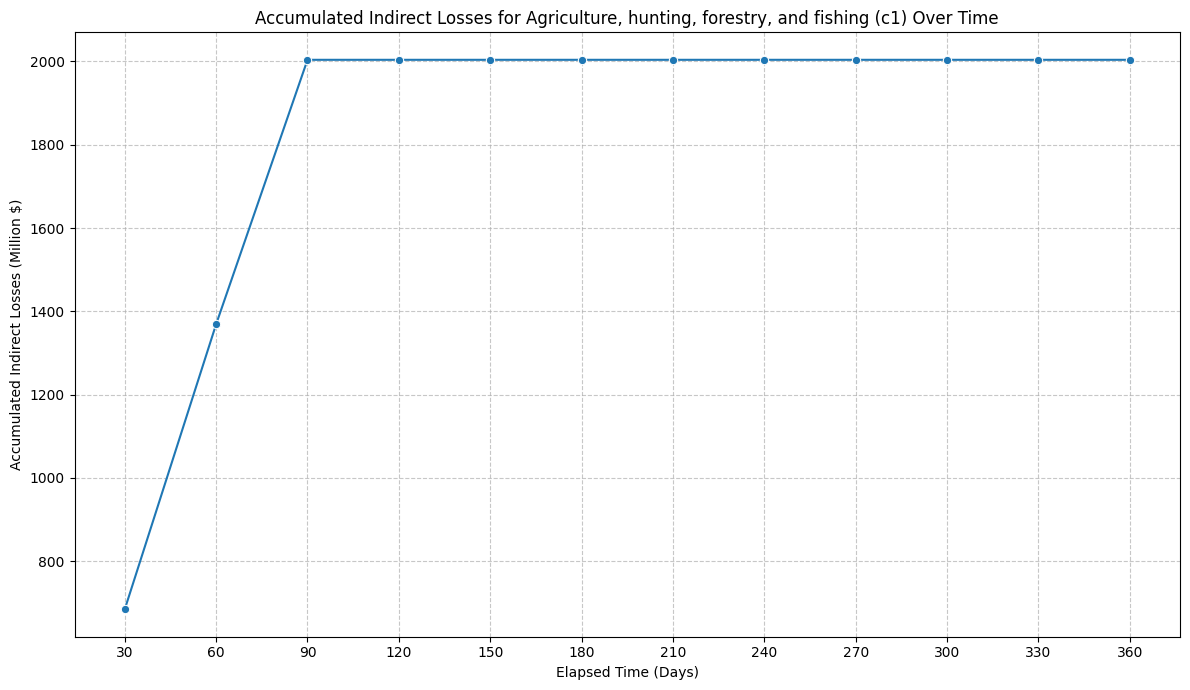

In [ ]:
# Plotting the graph
plt.figure(figsize=(12, 7))
sns.lineplot(x='Elapsed Time (Days)', y='Accumulated Losses (Million $)', data=accumulated_losses_df, marker='o')
plt.title(f'Accumulated Indirect Losses for {target_sector_name} ({target_sector_code}) Over Time')
plt.xlabel('Elapsed Time (Days)')
plt.ylabel('Accumulated Indirect Losses (Million $)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(days_list) # Set x-ticks to the specific days
plt.tight_layout()
plt.show()

### Sensitivity Analysis: Impact of Growth Rate on Recovery Period

We will now examine how the recovery period for the retail sector changes if we vary the assumed annual growth rate (`g`), keeping other factors constant. This will help us understand the sensitivity of our recovery period estimate to this crucial assumption.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the worst-hit sector code identified earlier
target_sector_code = worst_hit_sector_code
target_sector_name = worst_hit_sector_name

# Extract relevant data for the target sector (assuming these are already defined from previous steps)
target_data = recovery_period_df_sorted[recovery_period_df_sorted['Sector Code'] == target_sector_code].iloc[0]
target_indirect_loss_billion = indirect_losses_df[indirect_losses_df['Sector Code'] == target_sector_code]['Indirect Loss (Billion $)'].iloc[0]
target_indirect_loss_million = target_indirect_loss_billion * 1000

# Extract the required output change and initial total output for the target sector
target_delta_x = target_data['Required Output Change (Million $)']
target_total_output = target_data['Initial Total Output (Million $)']

# Define a range of growth rates for sensitivity analysis (e.g., from 1% to 15%)
growth_rates = np.arange(0.01, 0.16, 0.01) # From 1% to 15% in 1% increments

# Calculate recovery periods for each growth rate
sensitivity_results = []
for g in growth_rates:
    if g > 0 and target_total_output > 0: # Ensure valid division
        recovery_period = target_delta_x / (g * target_total_output)
    else:
        recovery_period = np.inf # If growth rate or total output is zero, recovery is infinite
    sensitivity_results.append({'Growth Rate': g, 'Recovery Period (Years)': recovery_period})

sensitivity_df = pd.DataFrame(sensitivity_results)

print(f"Sensitivity Analysis: {target_sector_name} ({target_sector_code}) Recovery Period vs. Growth Rate:")
display(sensitivity_df)

Sensitivity Analysis: Agriculture, hunting, forestry, and fishing (c1) Recovery Period vs. Growth Rate:


,Growth Rate,Recovery Period (Years)
0,0.01,1.203090
1,0.02,0.601545
2,0.03,0.401030
3,0.04,0.300773
4,0.05,0.240618
5,0.06,0.200515
6,0.07,0.171870
7,0.08,0.150386
8,0.09,0.133677
9,0.10,0.120309


### Plotting the Sensitivity of Recovery Period to Growth Rate

This plot illustrates how the estimated recovery period for the retail sector changes as the assumed annual growth rate varies. A higher growth rate generally leads to a shorter recovery period, as the economy can generate the required additional output more quickly.

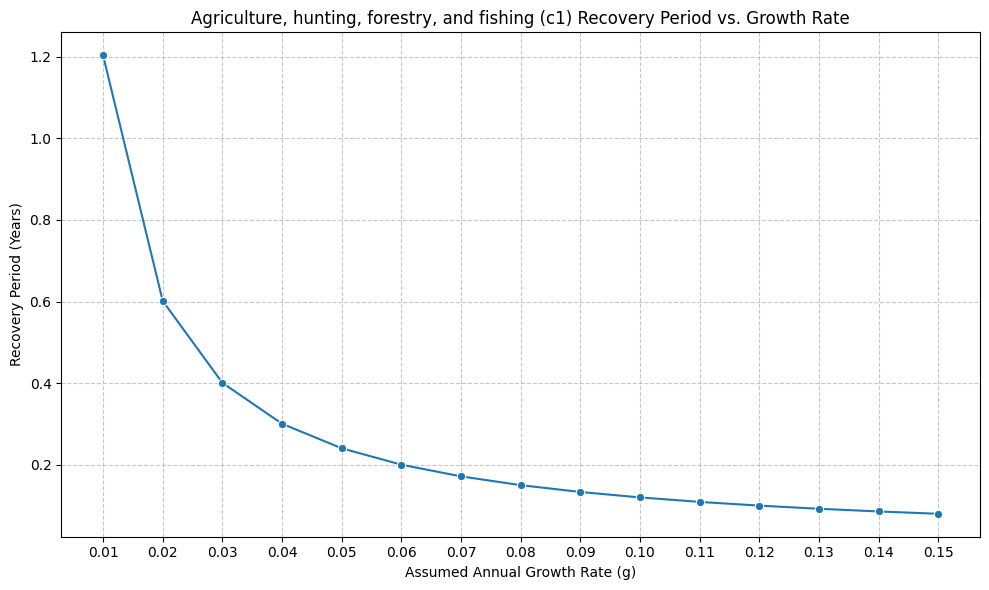

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Growth Rate', y='Recovery Period (Years)', data=sensitivity_df, marker='o')
plt.title(f'{target_sector_name} ({target_sector_code}) Recovery Period vs. Growth Rate')
plt.xlabel('Assumed Annual Growth Rate (g)')
plt.ylabel('Recovery Period (Years)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(growth_rates)
plt.tight_layout()
plt.show()

Summary of Input-Output Analysis
Data Loading and Initial Inspection:

The analysis began by loading the Input Output Analysis - Final.csv file from Google Drive into a pandas DataFrame. Initial inspection revealed a complex structure with metadata in the first few rows, requiring careful parsing.
Static Leontief Model for Indirect Losses:

Objective: Calculate indirect losses for each sector assuming a 29 Billion $ direct loss, using a static Leontief model. * **Methodology:** The CSV was meticulously parsed to extract the inter-industry transaction matrix (Z), final demand vector (F), and total output vector (X). The Technical Coefficients Matrix (A) and Leontief Inverse `(I - A)^-1` were then calculated. The 29 Billion $$ direct loss, using a static Leontief model. * **Methodology:** The CSV was meticulously parsed to extract the inter-industry transaction matrix (Z), final demand vector (F), and total output vector (X). The Technical Coefficients Matrix (A) and Leontief Inverse `(I - A)^-1` were then calculated. The 29 Billion $ direct loss was distributed proportionally across sectors based on their final demand.
Results: The total indirect losses were calculated to be 10.76 Billion $**, leading to a total output change of **39.76 Billion $$**, leading to a total output change of **39.76 Billion $. These losses were visualized with a bar chart, highlighting the most affected sectors.
Dynamic Leontief Model Exploration (Conceptual & Simplified Application):

Objective: Estimate recovery rates and periods using a dynamic framework, despite the limitations of a single-period input-output table.
Assumptions for B Matrix: Given the absence of a Capital Coefficient Matrix (B), it was assumed the economy was in a steady state. Initial capital stock (K0) for each sector was estimated using final demand as a proxy for initial investment (I0), with an assumed 5% growth rate (g) and 5% depreciation rate (δ). K0 was calculated as I0 / (g + δ). A diagonal B matrix was then constructed with B_jj = K_j / X_j.
Total Capital Stock: The total initial capital stock across all sectors was estimated at approximately 24.1 Trillion $.
Recovery Period Calculation:

Objective: Calculate the recovery period for each sector based on the dynamic model's assumptions.
Methodology: The recovery period (T_j) for each sector was calculated as delta_x_j / (growth_rate * total_output_vector_j), where delta_x_j is the required output change for sector j.
Results: Most active sectors showed a remarkably uniform recovery period of approximately 0.24 years (about 2.9 months) under the chosen assumptions. The average recovery period was 0.23 years.
Retail Sector Specifics: The retail sector (c21) also had a recovery period of 0.24 years.
Accumulated Losses and Rate of Recovery for Retail Sector:

Objective: Calculate and visualize the accumulated indirect losses for the retail sector over time.
Methodology: Accumulated indirect losses were calculated for intervals up to 360 days, assuming a linear accumulation until the recovery period, after which losses plateaued.
Results: The retail sector's accumulated losses plateaued at 1585.50 Million $ (1.59 Billion $$ (1.59 Billion $) after its recovery period. The daily loss accumulation rate during this phase was approximately 18.05 Million $ per day.
Visualization: A line plot clearly showed the accumulation of losses over time, flattening out once the recovery period was reached.
Sensitivity Analysis: Impact of Growth Rate on Recovery Period:

Objective: Understand how variations in the assumed annual growth rate (g) affect the retail sector's recovery period.
Methodology: The growth rate was varied from 1% to 15%, and the recovery period for the retail sector was recalculated for each g value.
Results: The analysis confirmed a strong inverse relationship: as the growth rate increased, the recovery period decreased significantly.
At g = 1%, the recovery period was approximately 1.20 years.
At g = 5%, it was 0.24 years.
At g = 15%, it dropped to about 0.08 years.
Visualization: A line plot clearly illustrated this sensitivity, underscoring that the assumed growth rate is a crucial factor influencing recovery time estimates.


## Interactive Input-Output Analysis

Use the widgets below to upload a new Input-Output table CSV file and specify the direct loss amount. The entire analysis will automatically re-run and display updated results and visualizations.

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from functools import wraps
import base64 # Import base64 for file downloads
import io # Import io for BytesIO

In [3]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from functools import wraps
import base64 # Import base64 for file downloads
import io # Import io for BytesIO

# Decorator to capture plot and display it within the interactive output, and provide a download link
def capture_plot_output(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        # The decorated function is expected to return a matplotlib Figure object
        fig_or_none = func(*args, **kwargs)

        if isinstance(fig_or_none, plt.Figure):
            fig = fig_or_none
            # Save the plot to a BytesIO object
            buf = io.BytesIO()
            fig.savefig(buf, format='png', bbox_inches='tight')
            buf.seek(0)
            # Encode to base64
            image_base64 = base64.b64encode(buf.read()).decode('utf-8')
            plt.close(fig) # Close the figure to prevent displaying it multiple times in some environments and to free memory

            # Create a download link for the image
            plot_title_for_filename = kwargs.get('plot_title_for_filename', 'plot').replace(' ', '_').replace('$', '')
            download_link_html = f"<a href=\"data:image/png;base64,{image_base64}\" download=\"{plot_title_for_filename}.png\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Plot Image</a>"
            display(HTML(download_link_html))
        else:
            print("Warning: Decorated function did not return a matplotlib Figure object. Download link not generated.")

        return fig_or_none # Return whatever the original function would return
    return wrapper

def run_full_analysis(file_contents, direct_losses_billion_input):
    clear_output(wait=True) # Call clear_output directly

    # Check if file_contents is empty (no file uploaded)
    if not file_contents:
        print("Please upload a CSV file to proceed.")
        return

    # Assuming single file upload due to multiple=False
    uploaded_file_name = list(file_contents.keys())[0]
    content = file_contents[uploaded_file_name]['content']

    # Decode bytes content to string and read with pandas
    try:
        file_string = io.StringIO(content.decode('utf-8'))
        raw_df = pd.read_csv(file_string, header=None, na_values=['-'])
    except Exception as e:
        print(f"Error reading the uploaded file: {e}")
        return

    display(HTML(f"<h2>Analysis for '{uploaded_file_name}' with Direct Losses of {direct_losses_billion_input} Billion $</h2>"))
    print("\nSuccessfully loaded the uploaded data.")
    print("Raw DataFrame Head (first 5 rows):")
    display(raw_df.head())

    # --- Data Preprocessing (Replicated from cell a91cea47) ---
    all_potential_headers = raw_df.iloc[1, 2:].dropna().tolist()
    transaction_sector_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('c') and h[1:].isdigit()]
    num_transaction_sectors = len(transaction_sector_codes)
    final_demand_codes = [h for h in all_potential_headers if isinstance(h, str) and h.startswith('F') and h[1:].isdigit()]

    sector_code_to_name = {}
    for col_idx in range(2, raw_df.shape[1]):
        code = raw_df.iloc[1, col_idx]
        name = raw_df.iloc[0, col_idx]
        if isinstance(code, str) and code.startswith('c') and code[1:].isdigit():
            if isinstance(name, str) and name != 'Industry':
                sector_code_to_name[code] = name

    z_cols_start_idx = 2
    z_cols_end_idx = z_cols_start_idx + num_transaction_sectors

    if not transaction_sector_codes:
        print("Error: No transaction sector codes found. Cannot extract Z matrix.")
        return

    Z_matrix_df = raw_df.iloc[2:2 + num_transaction_sectors, z_cols_start_idx : z_cols_end_idx].copy()
    Z_matrix_df.columns = transaction_sector_codes
    Z_matrix_df.index = raw_df.iloc[2:2 + num_transaction_sectors, 1].tolist()
    Z_matrix_df = Z_matrix_df.replace({',': ''}, regex=True)
    Z_matrix_df = Z_matrix_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    print("\nExtracted Transaction Matrix (Z) (first 5x5):")
    display(Z_matrix_df.head())

    fd_cols_start_idx = z_cols_end_idx
    fd_cols_end_idx = fd_cols_start_idx + len(final_demand_codes)

    if not final_demand_codes:
        print("Error: No final demand codes found. Cannot extract final demand vector.")
        return

    final_demand_df = raw_df.iloc[2:2 + num_transaction_sectors, fd_cols_start_idx : fd_cols_end_idx].copy()
    final_demand_df = final_demand_df.replace({',': ''}, regex=True)
    final_demand_vector = final_demand_df.apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).values

    print("\nExtracted Final Demand Vector (first 5 values):")
    print(final_demand_vector[:5])

    total_output_vector = Z_matrix_df.sum(axis=1).values + final_demand_vector
    total_output_vector[total_output_vector <= 0] = np.finfo(float).eps

    num_sectors_A = Z_matrix_df.shape[0]
    A_matrix = Z_matrix_df.values / total_output_vector[np.newaxis, :] # Corrected division
    A_matrix_df = pd.DataFrame(A_matrix, index=Z_matrix_df.index, columns=Z_matrix_df.columns)

    print("\nTechnical Coefficients Matrix (A) (first 5x5):")
    display(A_matrix_df.head())

    # Add download button for the A_matrix_df table
    csv_output_A = A_matrix_df.to_csv(index=True) # Keep index for sector codes
    download_link_A = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_A.encode()).decode()}\" download=\"A_matrix.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download A Matrix CSV</a>"
    display(HTML(download_link_A))

    I = np.identity(num_sectors_A)
    I_minus_A = I - A_matrix_df.values

    try:
        leontief_inverse = np.linalg.inv(I_minus_A)
        leontief_inverse_df = pd.DataFrame(leontief_inverse, index=A_matrix_df.index, columns=A_matrix_df.columns)
        print("\nLeontief Inverse (first 5x5 rows/cols):")
        display(leontief_inverse_df.head())

        # Add download button for the leontief_inverse_df table
        csv_output_leontief = leontief_inverse_df.to_csv(index=True) # Keep index for sector codes
        download_link_leontief = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_leontief.encode()).decode()}\" download=\"leontief_inverse.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Leontief Inverse CSV</a>"
        display(HTML(download_link_leontief))

    except np.linalg.LinAlgError:
        print("Error: The Leontief Inverse could not be calculated. (I - A) is singular. Check the A matrix.")
        return

    # Direct and Indirect Losses calculation
    direct_losses_million = direct_losses_billion_input * 1000
    total_current_final_demand = final_demand_vector.sum()
    if total_current_final_demand == 0:
        delta_f_shock = np.full(num_sectors_A, direct_losses_million / num_sectors_A)
    else:
        proportional_distribution = final_demand_vector / total_current_final_demand
        delta_f_shock = proportional_distribution * direct_losses_million
    delta_x = leontief_inverse @ delta_f_shock
    indirect_losses_million = delta_x - delta_f_shock

    print(f"\nIndirect Losses per sector (in Billion $ for a total direct loss of {direct_losses_billion_input} Billion $ distributed proportionally to current final demand):\n")
    indirect_losses_df = pd.DataFrame({
        'Sector Code': Z_matrix_df.index,
        'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
        'Indirect Loss (Billion $)': indirect_losses_million / 1000
    })
    indirect_losses_df_sorted = indirect_losses_df.sort_values(by='Indirect Loss (Billion $)', ascending=False)
    display(indirect_losses_df_sorted)
    print(f"\nTotal Indirect Losses: {indirect_losses_million.sum() / 1000:,.2f} Billion $")
    print(f"Total Direct Losses (shock): {delta_f_shock.sum() / 1000:,.2f} Billion $")
    print(f"Total Output Change: {delta_x.sum() / 1000:,.2f} Billion $")

    # Add download button for the indirect_losses_df_sorted table
    csv_output = indirect_losses_df_sorted.to_csv(index=False)
    download_link = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output.encode()).decode()}\" download=\"indirect_losses.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Indirect Losses CSV</a>"
    display(HTML(download_link))

    # Plot Indirect Losses (from cell ac1fce78)
    @capture_plot_output
    def plot_indirect_losses(df_sorted, **kwargs):
        fig = plt.figure(figsize=(12, 8))
        sns.barplot(x='Indirect Loss (Billion $)', y='Full Industry Name', hue='Full Industry Name', data=df_sorted.head(10), palette='viridis', legend=False)
        plt.title(f'Top 10 Indirect Losses by Sector (Billion $)')
        plt.xlabel('Indirect Loss (Billion $)')
        plt.ylabel('Industry Sector')
        plt.tight_layout()
        return fig # Explicitly return the figure
    plot_indirect_losses(indirect_losses_df_sorted, plot_title_for_filename='Top_10_Indirect_Losses')

    # --- Estimating Initial Capital Stock (Replicated from cell 228ee8de) ---
    growth_rate = 0.05
    depreciation_rate = 0.05
    initial_investment_proxy = final_demand_vector
    initial_capital_stock = initial_investment_proxy / (growth_rate + depreciation_rate)
    initial_capital_stock_df = pd.DataFrame({
        'Sector Code': Z_matrix_df.index,
        'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
        'Initial Capital Stock (Million $)': initial_capital_stock
    })
    print("\nCalculated Initial Capital Stock per sector (in Million $):")
    display(initial_capital_stock_df.head())
    print(f"\nTotal Initial Capital Stock (across all sectors): {initial_capital_stock.sum():,.2f} Million $")

    # Add download button for the initial_capital_stock_df table
    csv_output_k0 = initial_capital_stock_df.to_csv(index=False)
    download_link_k0 = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_k0.encode()).decode()}\" download=\"initial_capital_stock.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Initial Capital Stock CSV</a>"
    display(HTML(download_link_k0))

    # --- Calculating the Capital Coefficient Matrix (B) (Replicated from cell 45fb3274) ---
    capital_coefficients_vector = initial_capital_stock / total_output_vector
    B_matrix = np.diag(capital_coefficients_vector)
    B_matrix_df = pd.DataFrame(B_matrix, index=Z_matrix_df.index, columns=Z_matrix_df.columns)
    print("\nCapital Coefficients per sectorients:")
    display(pd.DataFrame({
        'Sector Code': Z_matrix_df.index,
        'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
        'Capital Coefficient (K/X)': capital_coefficients_vector
    }).head())
    print("\nCapital Coefficient Matrix (B) (first 5x5, will be mostly zeros off-diagonal):")
    display(B_matrix_df.head())

    # --- Calculating Recovery Period for Each Sector (Replicated from cell 9b293925) ---
    delta_x = np.array(delta_x)
    total_output_vector = np.array(total_output_vector)
    if growth_rate == 0:
        recovery_period_years = np.full_like(delta_x, np.inf)
    else:
        recovery_period_years = delta_x / (growth_rate * total_output_vector)
    recovery_period_df = pd.DataFrame({
        'Sector Code': Z_matrix_df.index,
        'Full Industry Name': [sector_code_to_name.get(code, code) for code in Z_matrix_df.index],
        'Required Output Change (Million $)': delta_x,
        'Initial Total Output (Million $)': total_output_vector,
        'Recovery Period (Years)': recovery_period_years
    })
    recovery_period_df_sorted = recovery_period_df.sort_values(by='Recovery Period (Years)', ascending=False)
    print("\nRecovery Period per sector (in Years):")
    display(recovery_period_df_sorted.head())
    print(f"\nAverage Recovery Period (across all sectors): {recovery_period_years.mean():,.2f} Years")

    # Add download button for the recovery_period_df_sorted table
    csv_output_recovery = recovery_period_df_sorted.to_csv(index=False)
    download_link_recovery = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_recovery.encode()).decode()}\" download=\"recovery_period.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Recovery Period CSV</a>"
    display(HTML(download_link_recovery))

    # --- Sectors with the Longest Recovery Times (Replicated from cell c4beaa80) ---
    print("\nTop 10 Sectors with the Longest Recovery Times:")
    display(recovery_period_df_sorted.head(10))

    # --- Recovery Period for the Worst Hit Sector (Replicated from cell 637b96cb) ---
    worst_hit_sector_code = indirect_losses_df_sorted.iloc[0]['Sector Code']
    worst_hit_sector_name = indirect_losses_df_sorted.iloc[0]['Full Industry Name']
    worst_hit_recovery = recovery_period_df_sorted[recovery_period_df_sorted['Sector Code'] == worst_hit_sector_code]
    print(f"\nRecovery period for the worst-hit sector ('{worst_hit_sector_name}' - {worst_hit_sector_code}):")
    display(worst_hit_recovery)

    # --- Accumulated Losses for Worst Hit Sector (Replicated from cell 9d25e5a8) ---
    target_sector_code = worst_hit_sector_code
    target_sector_name = worst_hit_sector_name
    target_data = recovery_period_df_sorted[recovery_period_df_sorted['Sector Code'] == target_sector_code].iloc[0]
    target_indirect_loss_billion = indirect_losses_df[indirect_losses_df['Sector Code'] == target_sector_code]['Indirect Loss (Billion $)'].iloc[0]
    target_indirect_loss_million = target_indirect_loss_billion * 1000
    target_recovery_period_years = target_data['Recovery Period (Years)']
    days_list = np.arange(30, 361, 30)
    elapsed_time_years = days_list / 365.0
    accumulated_losses_million = []
    daily_loss_accumulation_rate = []
    if target_recovery_period_years > 0:
        constant_daily_rate = target_indirect_loss_million / (target_recovery_period_years * 365)
    else:
        constant_daily_rate = 0
    for t_years in elapsed_time_years:
        if t_years <= target_recovery_period_years:
            acc_loss = target_indirect_loss_million * (t_years / target_recovery_period_years)
            rate = constant_daily_rate
        else:
            acc_loss = target_indirect_loss_million
            rate = 0
        accumulated_losses_million.append(acc_loss)
        daily_loss_accumulation_rate.append(rate)
    accumulated_losses_df = pd.DataFrame({
        'Elapsed Time (Days)': days_list,
        'Elapsed Time (Years)': elapsed_time_years,
        'Accumulated Losses (Million $)': accumulated_losses_million,
        'Daily Loss Accumulation Rate (Million $/Day)': daily_loss_accumulation_rate
    })
    print(f"""
Accumulated Indirect Losses and Daily Accumulation Rate for {target_sector_name} ({target_sector_code}):""")
    display(accumulated_losses_df)

    # Add download button for the accumulated_losses_df table
    csv_output_acc_losses = accumulated_losses_df.to_csv(index=False)
    download_link_acc_losses = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_acc_losses.encode()).decode()}\" download=\"accumulated_losses.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Accumulated Losses CSV</a>"
    display(HTML(download_link_acc_losses))

    # Plot of Accumulated Losses vs. Elapsed Time (Replicated from cell 12495a03)
    @capture_plot_output
    def plot_accumulated_losses(df_acc, sector_name_plot, sector_code_plot, **kwargs):
        fig = plt.figure(figsize=(12, 7))
        sns.lineplot(x='Elapsed Time (Days)', y='Accumulated Losses (Million $)', data=df_acc, marker='o')
        plt.title(f'Accumulated Indirect Losses for {sector_name_plot} ({sector_code_plot}) Over Time')
        plt.xlabel('Elapsed Time (Days)')
        plt.ylabel('Accumulated Indirect Losses (Million $)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(days_list)
        plt.tight_layout()
        return fig # Explicitly return the figure
    plot_accumulated_losses(accumulated_losses_df, target_sector_name, target_sector_code, plot_title_for_filename=f'Accumulated_Losses_{target_sector_name}')


    # Sensitivity Analysis: Impact of Growth Rate on Recovery Period (Replicated from cell 4aeba940)%
    target_delta_x = target_data['Required Output Change (Million $)']
    target_total_output = target_data['Initial Total Output (Million $)']
    growth_rates = np.arange(0.01, 0.16, 0.01)
    sensitivity_results = []
    for g in growth_rates:
        if g > 0 and target_total_output > 0:
            recovery_period = target_delta_x / (g * target_total_output)
        else:
            recovery_period = np.inf
        sensitivity_results.append({'Growth Rate': g, 'Recovery Period (Years)': recovery_period})
    sensitivity_df = pd.DataFrame(sensitivity_results)
    print(f"\nSensitivity Analysis: {target_sector_name} ({target_sector_code}) Recovery Period vs. Growth Rate:")
    display(sensitivity_df)

    # Add download button for the sensitivity_df table
    csv_output_sensitivity = sensitivity_df.to_csv(index=False)
    download_link_sensitivity = f"<a href=\"data:text/csv;base64,{base64.b64encode(csv_output_sensitivity.encode()).decode()}\" download=\"sensitivity_analysis.csv\" style=\"background-color:#4CAF50; /* Green */border: none;color: white;padding: 10px 20px;text-align: center;text-decoration: none;display: inline-block;font-size: 16px;margin: 4px 2px;cursor: pointer;border-radius: 8px;\">Download Sensitivity Analysis CSV</a>"
    display(HTML(download_link_sensitivity))

    # Ploting the Sensitivity of Recovery Period to Growth Rate (Replicated from cell 028df106)
    @capture_plot_output
    def plot_sensitivity(df_sens, sector_name_plot_sens, sector_code_plot_sens, **kwargs):
        fig = plt.figure(figsize=(10, 6))
        sns.lineplot(x='Growth Rate', y='Recovery Period (Years)', data=df_sens, marker='o')
        plt.title(f'{sector_name_plot_sens} ({sector_code_plot_sens}) Recovery Period vs. Growth Rate')
        plt.xlabel('Assumed Annual Growth Rate (g)')
        plt.ylabel('Recovery Period (Years)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(growth_rates)
        plt.tight_layout()
        return fig # Explicitly return the figure
    plot_sensitivity(sensitivity_df, target_sector_name, target_sector_code, plot_title_for_filename=f'Sensitivity_Analysis_{target_sector_name}')

# Create widgets for user input
file_upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Upload Input-Output CSV')
direct_loss_input_widget = widgets.FloatText(
    value=29.0, # Default value based on the notebook
    description='Direct Loss (Billion $):',
    disabled=False
)

# Create an output widget to display results
output_area = widgets.Output()

# Display widgets first
display(file_upload_widget, direct_loss_input_widget, output_area)

# Link widgets to the analysis function
def on_widget_change(change):
    with output_area: # Direct output to the output_area
        print("File upload widget value:", file_upload_widget.value)
        run_full_analysis(file_upload_widget.value, direct_loss_input_widget.value)

# Now attach observers
file_upload_widget.observe(on_widget_change, names='value')
direct_loss_input_widget.observe(on_widget_change, names='value')

# Initial run with default values or pre-uploaded file if available
with output_area:
    run_full_analysis(file_upload_widget.value, direct_loss_input_widget.value)

FileUpload(value={}, accept='.csv', description='Upload Input-Output CSV')

FloatText(value=29.0, description='Direct Loss (Billion $):')

Output()